<a href="https://colab.research.google.com/github/kikeblancakhaldy/Procesos_Estocasticos/blob/main/PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del *Paseo Aleatorio Simple* (PAS)

El Paseo Aleatorio Simple es un proceso estocástico $\{X_i\}_{i\in \mathbb{N}}$ con $X_k=\sum_{i=1}^kZ_i$, $\forall k\in \mathbb{N}$, siendo $\{Z_i\}_{i\in \mathbb{N}}$ una familia de variables aleatorias independientes e idénticamente distribuidas que toman el valor $1$ con probabilidad $p$ y el valor $-1$ con probabilidad $1-p$.

Intuitivamente, el PAS representa el movimiento aleatorio de una partícula que en cada unidad de tiempo puede avanzar o retroceder con cierta probabilidad.

Para simularlo, primero necesitamos definir una función núcleo `simular_PAS(n,p,reps)` que nos devolverá una matriz de tamaño $reps$ x $n$ donde cada fila será una simulación diferente del PAS y cada columna será cada paso.

Representemos varias simulaciones en una misma gráfica:

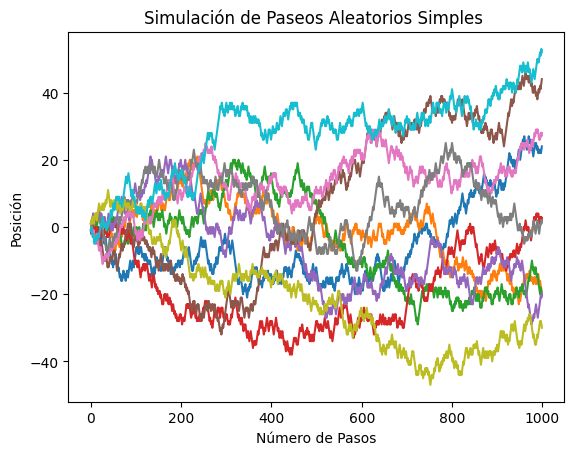

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simular_PAS(n,p,reps):
  #p es la probabilidad de que la variable de un paso hacia delante
  #n es el numero de pasos que daremos en este paseoa aleatorio simple

  #cada fila de esta matriz representa cuando subimos y cuando bajamos en cada repeticion del PAS
  pasos=np.random.choice([1, -1], size=(reps,n), p=[p,1-p])
  pas= np.cumsum(pasos, axis=1) #aquí colocamos en cada columna de la matriz la suma de todas las columnas anteriores
  media=(2*p -1)*np.arange(1,n+1)#calculamos la media teórica del PAS
  desviacion_tipica=np.sqrt(np.arange(1,n+1) * 4 * p * (1-p))#calculamos la desviación típica teórica del PAS
  return pas # Shape: (reps, n)


#inicializamos las variables con los valores que queramos:
p=0.5
n=1000
reps=10

pasos= simular_PAS(n,p,reps)
plt.plot(pasos .T) # trasponemos la matriz para que el eje de los pasos coincida con el eje X

plt.title('Simulación de Paseos Aleatorios Simples ')
plt.xlabel('Número de Pasos')
plt.ylabel('Posición')
plt.show()

Ahora, representaremos las simulaciones de Paseos Aleatorios Simples con la media y desviación típica teóricas:

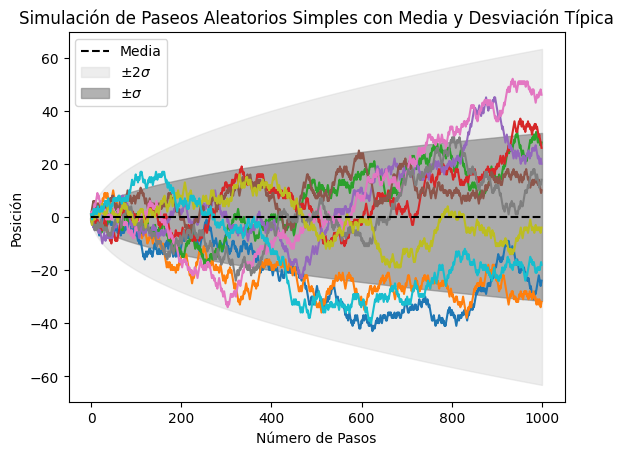

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular_PAS(n,p,reps):
  #p es la probabilidad de que la variable de un paso hacia delante
  #n es el numero de pasos que daremos en este paseoa aleatorio simple

  #cada fila de esta matriz representa cuando subimos y cuando bajamos en cada repeticion del PAS
  pasos=np.random.choice([1, -1], size=(reps,n), p=[p,1-p])
  pas= np.cumsum(pasos, axis=1) #aquí colocamos en cada columna de la matriz la suma de todas las columnas anteriores
  media=(2*p -1)*np.arange(1,n+1)#calculamos la media teórica del PAS
  desviacion_tipica=np.sqrt(np.arange(1,n+1) * 4 * p * (1-p))#calculamos la desviación típica teórica del PAS
  return pas # Shape: (reps, n)


#inicializamos las variables con los valores que queramos:
p=0.5
n=1000
reps=10

pasos= simular_PAS(n,p,reps)
# a continuación generamos una partición del eje X para representar la media y la desviación típica teóricas
x_values = np.arange(1, n+ 1)
media=(2*p -1)*np.arange(1,n+1)#calculamos la media teórica del PAS
desviacion_tipica=np.sqrt(np.arange(1,n+1) * 4 * p * (1-p))#calculamos la desviación típica teórica del PAS
plt.plot(pasos .T)
plt.plot(media, color='black', linestyle='--', label='Media')

#aquí visualizamos la región de desviación típica
plt.fill_between(x_values, media - 2*desviacion_tipica, media + 2*desviacion_tipica, color='lightgray', alpha=0.4, label=r'$\pm2\sigma$')
#aquí visualizamos la región que nos marca que doble de la desviación típica
plt.fill_between(x_values, media - desviacion_tipica, media + desviacion_tipica, color='gray', alpha=0.6, label=r'$\pm\sigma$')

plt.legend()
plt.title('Simulación de Paseos Aleatorios Simples con Media y Desviación Típica')
plt.xlabel('Número de Pasos')
plt.ylabel('Posición')
plt.show()

Por último, veamos de manera visual cómo la media empírica se va aproximando más y más a la media teórica cada vez que añadimos más simulaciones del  PAS:

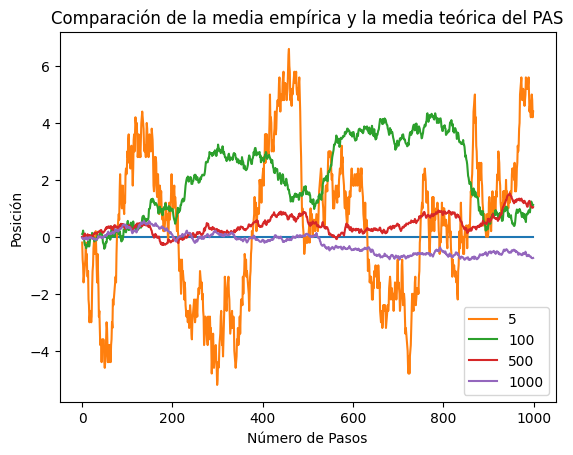

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular_PAS(n,p,reps):
  #p es la probabilidad de que la variable de un paso hacia delante
  #n es el numero de pasos que daremos en este paseoa aleatorio simple

  #cada fila de esta matriz representa cuando subimos y cuando bajamos en cada repeticion del PAS
  pasos=np.random.choice([1, -1], size=(reps,n), p=[p,1-p])
  pas= np.cumsum(pasos, axis=1) #aquí colocamos en cada columna de la matriz la suma de todas las columnas anteriores


  return pas # Shape: (reps, n)
p=0.5
n=1000
media=(2*p -1)*np.arange(1,n+1)

plt.plot(media)
plt.plot(np.mean(simular_PAS(n,p,5), axis=0), label='5') #cada número de la leyenda representa el número de simulaciones
plt.plot(np.mean(simular_PAS(n,p,100), axis=0), label='100')
plt.plot(np.mean(simular_PAS(n,p,500), axis=0), label='500')
plt.plot(np.mean(simular_PAS(n,p,1000), axis=0),label='1000')
plt.legend()
plt.title('Comparación de la media empírica y la media teórica del PAS')
plt.xlabel('Número de Pasos')
plt.ylabel('Posición')
plt.show()